# **MACHINE LEARNING**

#### Submitted by: SATISH KUMAR

## **Part B: Customer Churn Prediction**

**1. Overview**

Customer churn, or customer attrition, refers to when a customer ceases their relationship
with a company or service provider. In today's highly competitive business environment,
retaining customers is a critical factor for long-term success. Predicting customer churn can
help organizations take proactive steps to retain customers, thus minimizing revenue loss.
This project aims to build a machine learning model that can predict whether a customer will
churn based on their demographic, account, and service-related data.

**2. Problem Statement**

The goal of this project is to develop a classification model that predicts whether a customer
will churn. Using demographic data (such as gender, senior citizen status, and tenure), along
with information about the services they use (such as internet service, phone service, and
online security), we will attempt to build a model that helps the company identify customers
who are at a high risk of churning.
By predicting customer churn, the company can proactively design retention strategies to
keep these customers, thereby improving customer satisfaction and reducing financial loss.

**3. Dataset Information**

Dataset: Customer_data
The dataset information can be found in this doc Data Information.

**4. Deliverables**

● A data exploration and preprocessing notebook or report that analyzes the dataset,
handles missing values, and prepares the data for modeling. 

● A machine learning model capable of predicting customer churn. 

● An evaluation of model performance using appropriate metrics (such as accuracy,
precision, recall, F1 score, etc.). 

● Final video clip of candidate summarizing the entire process of the project as the
presentation. (Note: Video should not exceed 5 mins) 

**5. Success Criteria**

The success of the project will be determined by the following:

● Proper interpretation of the model’s output, providing actionable insights to reduce
customer churn.

● Get the predictions for the new data.

**6. Guidelines**

● Make sure to split your data into training and testing sets to avoid overfitting.

● Tune the hyperparameters of your models to improve performance.

● Report all the steps taken in the data preprocessing, modeling, and evaluation
phases.

● Provide a final model that balances accuracy with interpretability.

**7. Tools Required**

● Python (with libraries such as pandas, scikit-learn, matplotlib, seaborn, etc.)

● Jupyter Notebook or any IDE suitable for running Python code.

## **Phase 1: Data Processing**

### Step1: Import the Libraies and Load the Datasets

In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Load dataset
churn_data = pd.read_csv('Customer_data - customer_data.csv')

In [6]:
churn_data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [7]:
print(churn_data.isnull().sum())

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64


### Step2: Display the Dataset Information

In [8]:
# Display basic information and structure
print(churn_data.describe(include='all'))  # Get summary statistics

        customerID gender  SeniorCitizen Partner Dependents       tenure  \
count         7043   7043    7043.000000    7043       7043  7043.000000   
unique        7043      2            NaN       2          2          NaN   
top     3186-AJIEK   Male            NaN      No         No          NaN   
freq             1   3555            NaN    3641       4933          NaN   
mean           NaN    NaN       0.162147     NaN        NaN    32.371149   
std            NaN    NaN       0.368612     NaN        NaN    24.559481   
min            NaN    NaN       0.000000     NaN        NaN     0.000000   
25%            NaN    NaN       0.000000     NaN        NaN     9.000000   
50%            NaN    NaN       0.000000     NaN        NaN    29.000000   
75%            NaN    NaN       0.000000     NaN        NaN    55.000000   
max            NaN    NaN       1.000000     NaN        NaN    72.000000   

       PhoneService MultipleLines InternetService OnlineSecurity  ...  \
count         

## **Phase 3: Data Cleaning**

### Step1: Check null values

In [9]:
print(churn_data.info())  # Get data types and missing values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


### Step2: Missing values

In [11]:
churn_data.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

### Results

Total Charges: 11 values is missing

## **Phase 2: Exploratory Data Analysis EDA**

### Step1: Distribution Analysis

#### A. Distribution by Charn

C:\Users\Satish\AppData\Local\Temp\ipykernel_19636\1926444650.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=churn_data, x='Churn', palette='coolwarm')


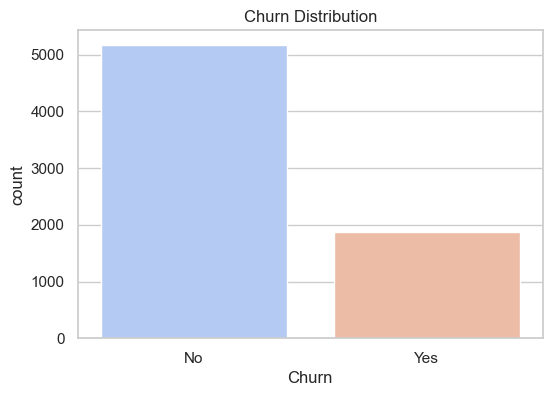

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import math


sns.set(style="whitegrid")

# 1. Churn Distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=churn_data, x='Churn', palette='coolwarm')
plt.title("Churn Distribution")
plt.show()

**Results**: Dataset is imbalanced; more non-churners than churners.

#### B. Churn by Gender

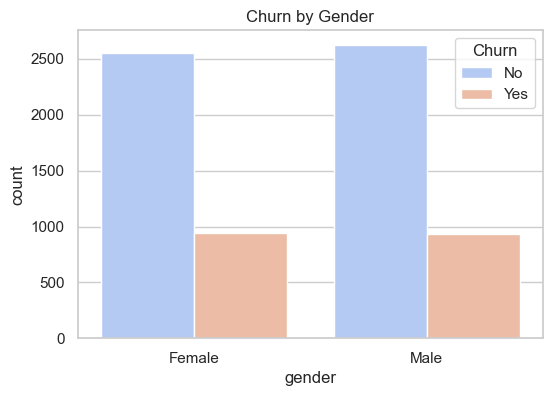

In [18]:
# 2. Churn by Gender
plt.figure(figsize=(6, 4))
sns.countplot(data=churn_data, x='gender', hue='Churn', palette='coolwarm')
plt.title("Churn by Gender")
plt.show()

**Results**:Senior citizens are more likely to churn.

#### C. Churn by Senior Citizen

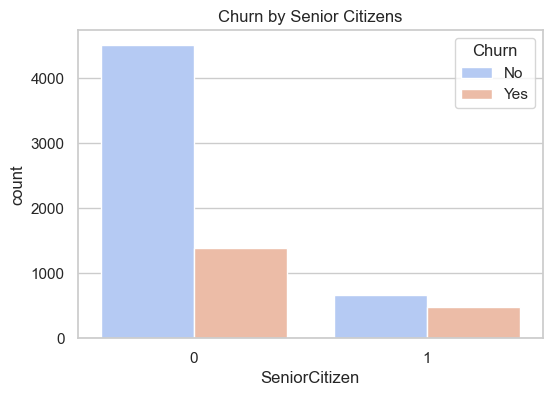

In [21]:
# 3. Churn by SeniorCitizen
plt.figure(figsize=(6, 4))
sns.countplot(data=churn_data, x='SeniorCitizen', hue='Churn', palette='coolwarm')
plt.title("Churn by Senior Citizens")
plt.show()

**Results:** Customers using fiber optic services churn more than DSL users.

#### D. Churn by Internet Service Type

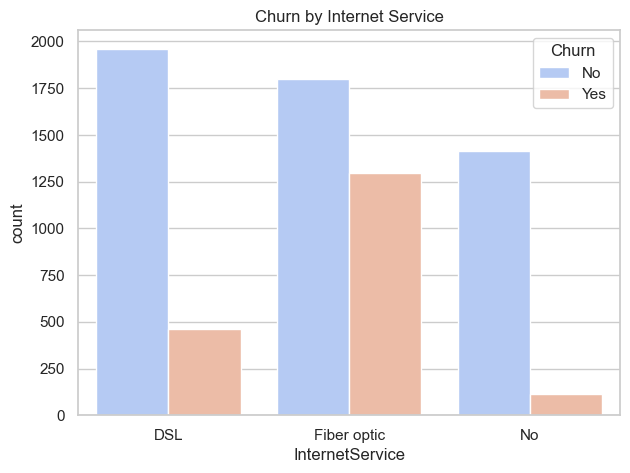

In [24]:
# 4. Churn by Internet Service Type
plt.figure(figsize=(7, 5))
sns.countplot(data=churn_data, x='InternetService', hue='Churn', palette='coolwarm')
plt.title("Churn by Internet Service")
plt.show()

**Results**: Higher monthly charges correlate with a higher likelihood of churn.
Long-tenured customers are less likely to churn.

### E. Histogram of Numeric Features

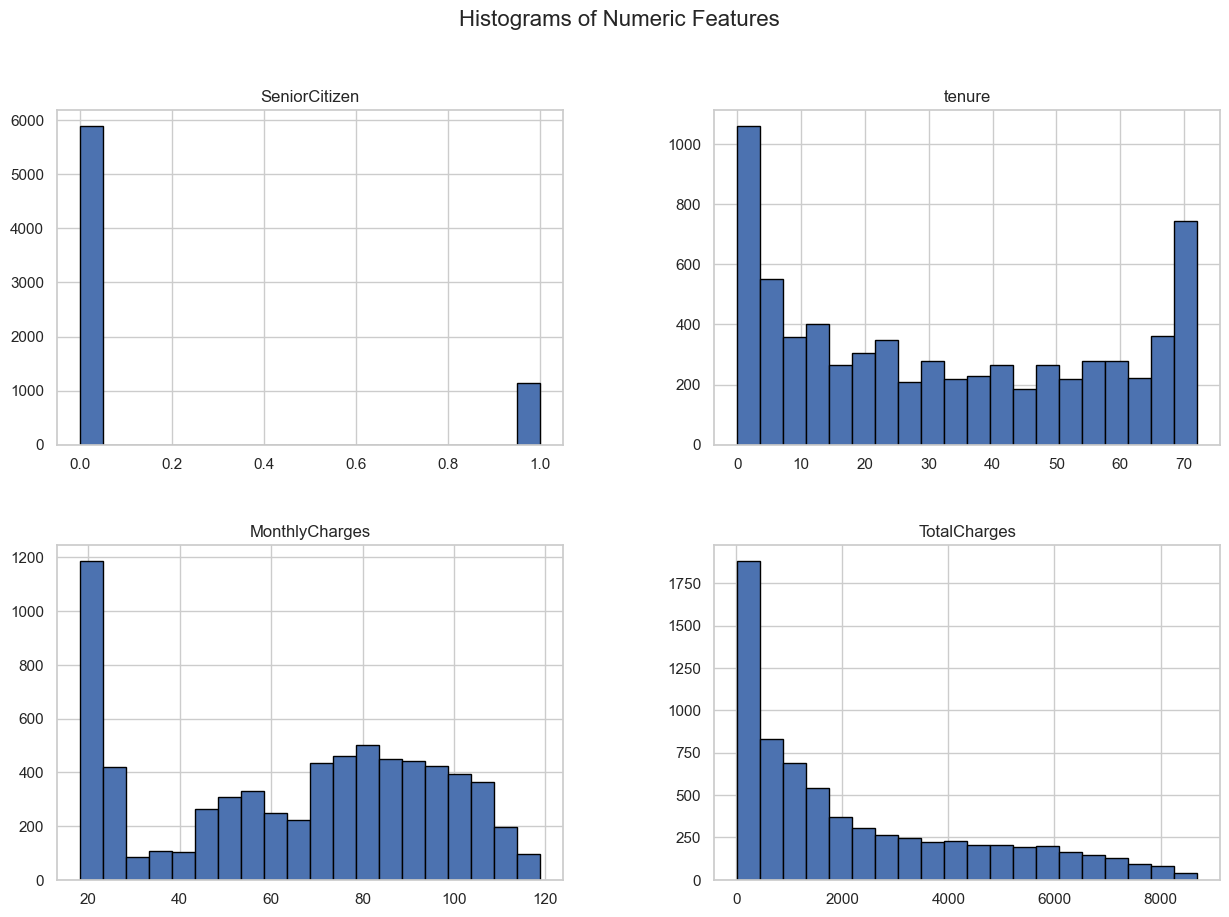

In [27]:
# Plotting distributions of numeric features
churn_data.hist(bins=20, figsize=(15, 10), edgecolor='black')
plt.suptitle('Histograms of Numeric Features', fontsize=16)
plt.show()

#### The four graphs show that these variables have very different distributions:

**Feature**	**Distribution / Observation**	**Main EDA Finding**

- SeniorCitizen:	**Binary**	Majority are non-senior citizens

- tenure:	**Uneven/U-shaped**	Many customers are either very new or long-term

- MonthlyCharges:	**Broad, somewhat multi-modal**	Charges vary substantially across customers

- TotalCharges:	**Strong right-skew**	Many customers have relatively low total charges, while fewer have very high totals

- Outliers:	**Few obvious outliers**	Continuous variables don't show serious extreme outliers

- Relationships:	**Strong relationships involving** TotalCharges	TotalCharges is strongly related to tenure and MonthlyCharges

#### F. Numerical Columns Features

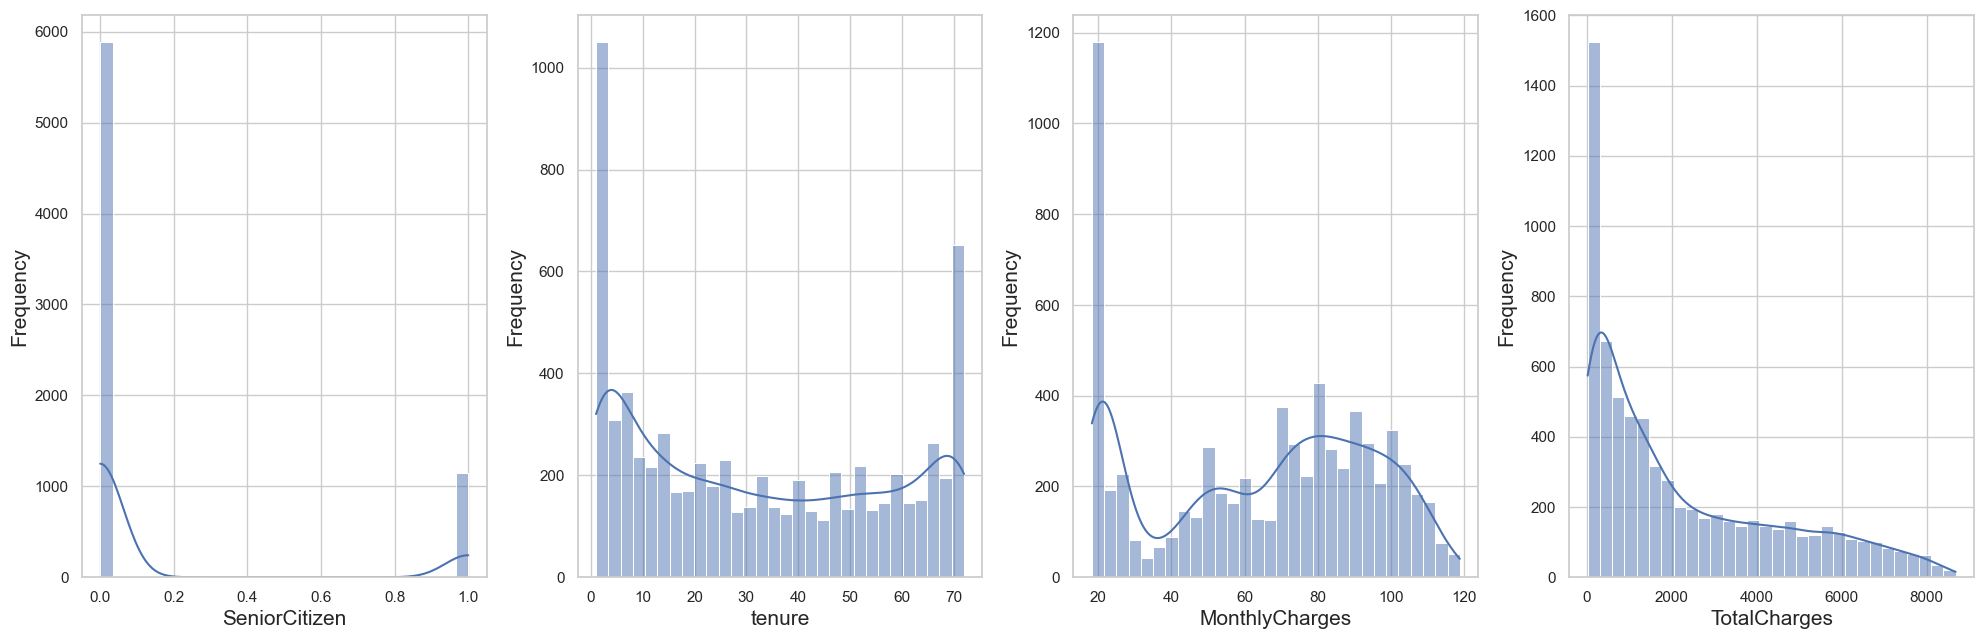

In [29]:
import numpy as np

# Filter only numerical columns
numerical_columns = churn_data.select_dtypes(include=np.number).columns

# Drop rows with NaN values once
data_cleaned = churn_data.dropna(subset=numerical_columns)

# Set up the figure
plt.figure(figsize=(20, 25))
plotnumber = 1

# Loop through numerical columns
for column in numerical_columns:
    if plotnumber <= 16:  # Adjust this limit as per your requirement
        ax = plt.subplot(4, 4, plotnumber)  # 4x4 grid
        sns.histplot(x=data_cleaned[column] , kde=True, bins=30)
        plt.xlabel(column, fontsize=15)
        plt.ylabel('Frequency', fontsize=15)
        plotnumber += 1

plt.tight_layout()
plt.show()


### The numerical feature analysis shows that the dataset contains four numerical variables: SeniorCitizen, tenure, MonthlyCharges, and TotalCharges.

- SeniorCitizen is a binary variable with substantially more non-senior customers than senior customers.

- Tenure has an uneven distribution, containing both newer and long-term customers. -

- MonthlyCharges has a broad distribution, indicating considerable variation in customers' monthly spending.

- TotalCharges is strongly right-skewed, with most customers having lower accumulated charges and fewer customers having very high accumulated charges.

#### G. Scatter Plot

<Figure size 2000x2500 with 0 Axes>

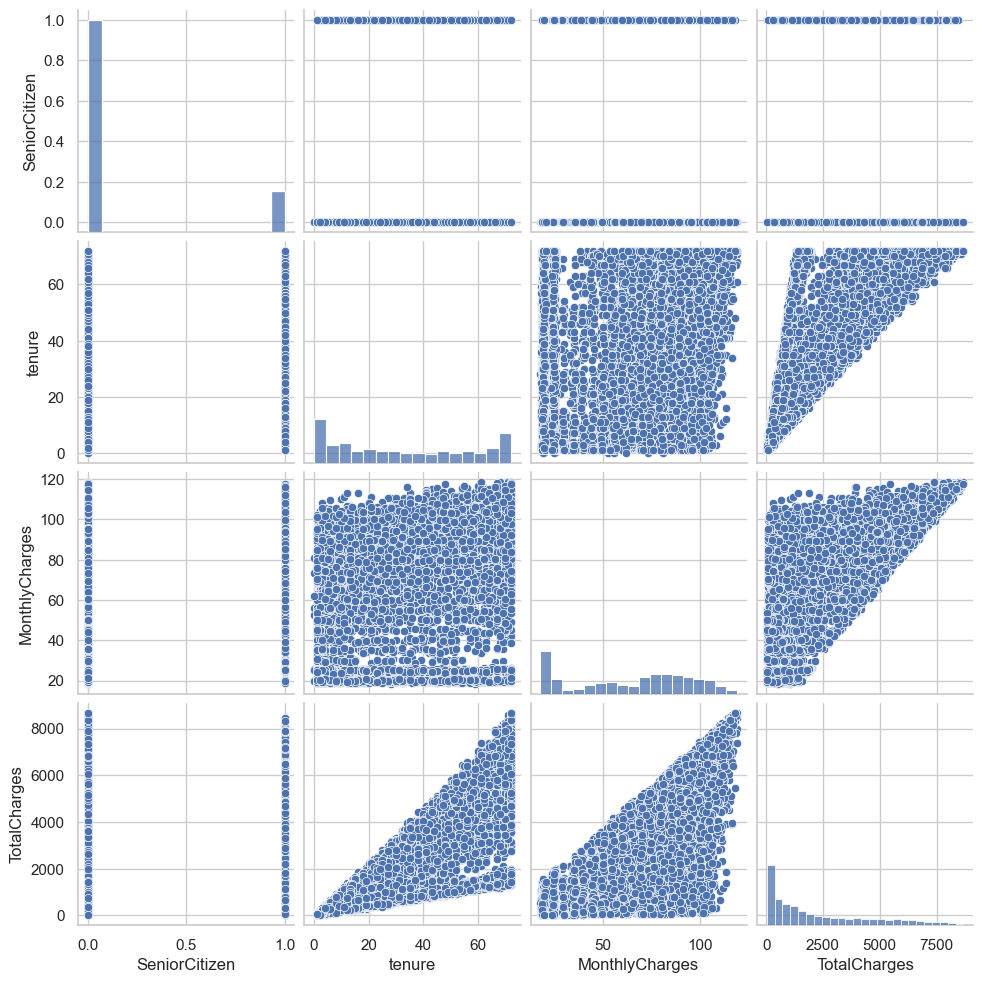

In [31]:
plt.figure(figsize=(20, 25))
sns.pairplot(churn_data)

### Results

- The scatter plot indicates a **strong positive relationship** between **tenure** and **TotalCharges**, as well as between **MonthlyCharges** and **TotalCharges**.

- These relationships are expected because TotalCharges accumulates billing over the customer's service period.

- The relationship between **tenure** and **Monthly Charges** appears comparatively **weak**.

## **Phase 4: Data Preprocessing**

### Step1: Box Plot Graph

#### A. Box Plot Graph

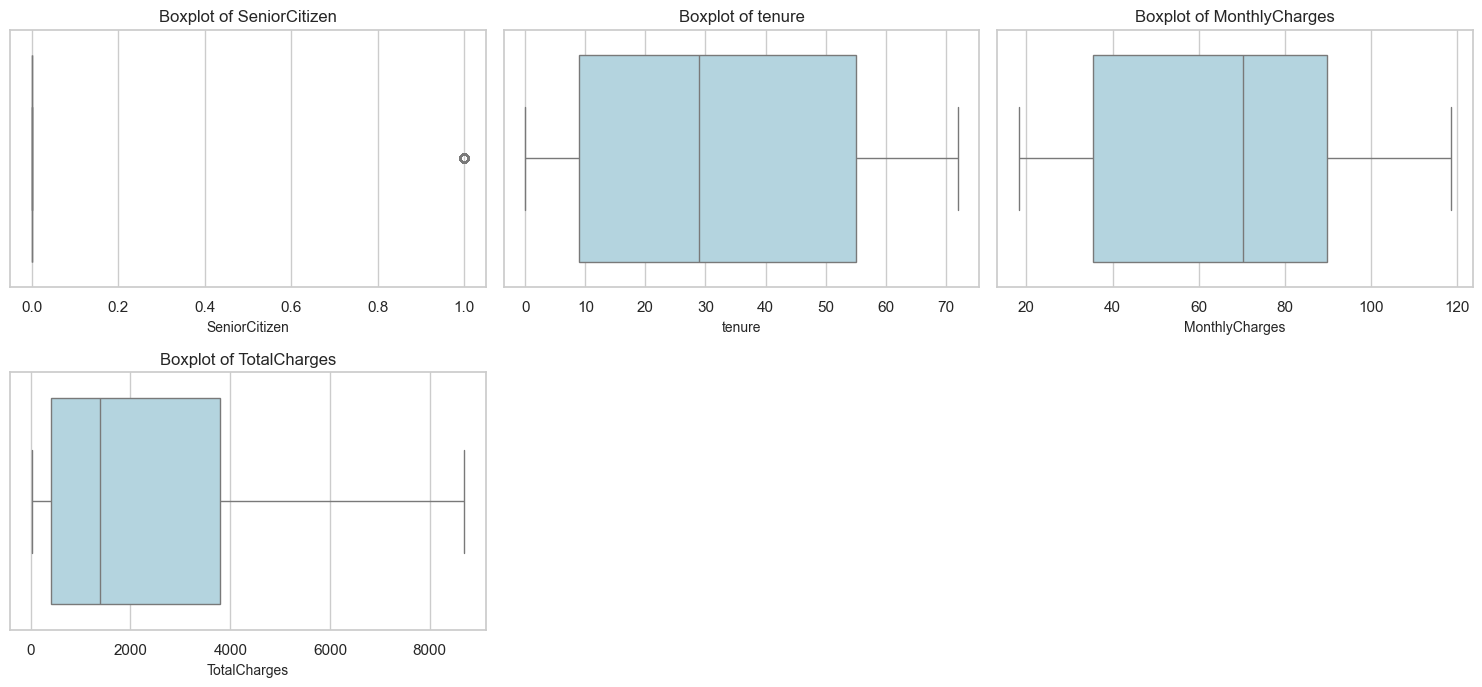

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

# List of numeric columns in the dataset
numeric_columns = churn_data.select_dtypes(include=['number']).columns

# Set up the plot size
plt.figure(figsize=(15, 10))

# Loop through each numeric column and create a boxplot
for i, column in enumerate(numeric_columns, 1):
    plt.subplot(3, 3, i)  # Adjust the number of rows and columns as needed
    sns.boxplot(x=churn_data[column], color='lightblue')
    plt.title(f'Boxplot of {column}', fontsize=12)
    plt.xlabel(column, fontsize=10)

# Display the plots
plt.tight_layout()
plt.show()


### Results

- The box plots **do not show major extreme outliers** in the continuous numerical variables.

- Therefore, there is no strong evidence that the continuous variables require aggressive outlier removal.

- SeniorCitizen is binary and should be treated as a categorical/binary variable rather than as a continuous numerical variable.

#### B. Bar Graph: Churn by Contract Type

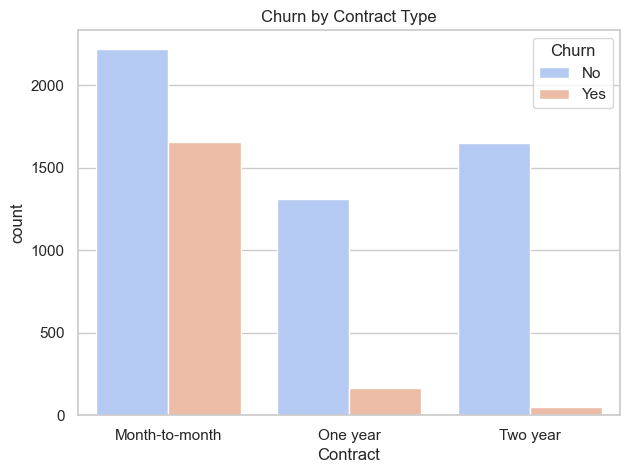

In [36]:
# 9. Churn by Contract Type
plt.figure(figsize=(7, 5))
sns.countplot(data=churn_data, x='Contract', hue='Churn', palette='coolwarm')
plt.title("Churn by Contract Type")
plt.show()

### Results

#### Churn by Contract Type

- Month-to-month customers have the highest churn by a large margin.

- One-year and two-year contract customers have much lower churn.

- This suggests that long-term contracts are associated with better customer retention.

- Actionable insight: Encourage month-to-month customers to switch to one-year or two-year contracts through discounts, loyalty benefits, or contract incentives.

#### C. Bar Graph: Churn by Payment Method

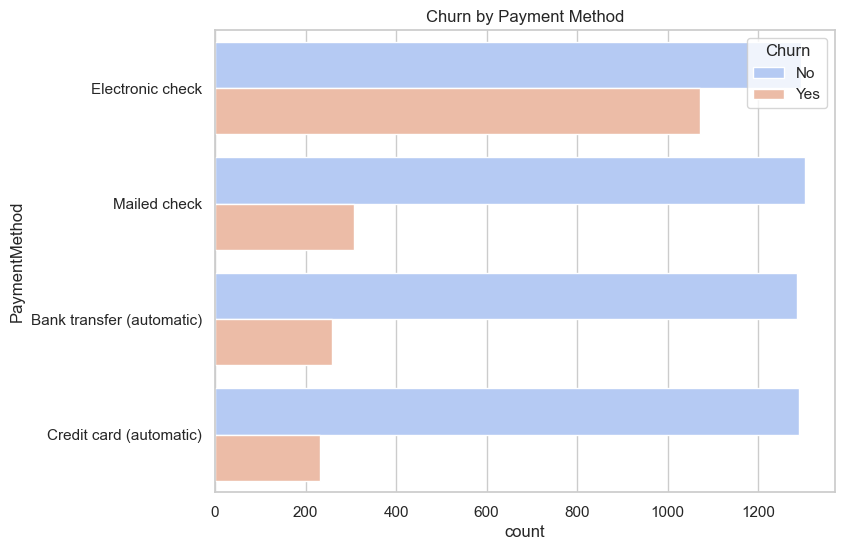

In [38]:
# 10. Churn by Payment Method
plt.figure(figsize=(8, 6))
sns.countplot(data=churn_data, y='PaymentMethod', hue='Churn', palette='coolwarm')
plt.title("Churn by Payment Method")
plt.show()

### Results

#### Churn by Payment Method

- Electronic check customers show the highest churn compared with the other payment methods.

- Customers using credit card, bank transfer, and mailed check have considerably lower churn counts.

- Actionable insight: Investigate why electronic-check customers are more likely to churn and consider encouraging automatic payment methods or providing incentives for switching

### Step2: Clean the data

#### A. Check missing values

In [41]:
print(churn_data.isnull().sum())

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64


#### B. Handle Missing Values

In [43]:
# Fill missing values in 'TotalCharges' column with the median
churn_data['TotalCharges'] = churn_data['TotalCharges'].fillna(churn_data['TotalCharges'].median())

In [44]:
print(churn_data.isnull().sum())

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


## **Phase 5: Feature Engineering**

### Step1: Apply Coorelation Heatmap

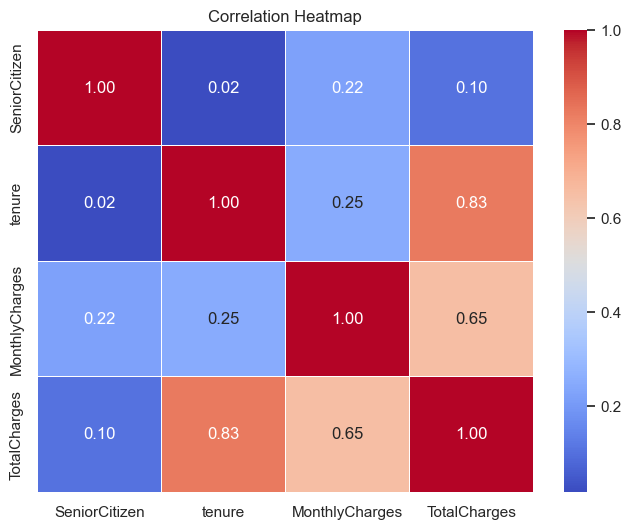

In [47]:
plt.figure(figsize=(8, 6))
numeric_columns = ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
corr = churn_data[numeric_columns].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

**Correlation Heatmap**

- Tenure ↔ TotalCharges: 0.83 → strong positive correlation.

- MonthlyCharges ↔ TotalCharges: 0.65 → moderately strong positive correlation.

- Tenure ↔ MonthlyCharges: 0.25 → weak positive correlation.

- SeniorCitizen has weak correlations with the other numerical variables.

- The strong tenure–TotalCharges relationship is expected because customers who stay longer generally accumulate higher total charges.

## **Phase 6: Data Modeling**

### **Step1: Import Imbalanced-learn**

In [50]:
import sys

print(sys.executable)
print(sys.version)

C:\Users\Satish\AppData\Local\Programs\Python\Python313\python.exe
3.13.5 (tags/v3.13.5:6cb20a2, Jun 11 2025, 16:15:46) [MSC v.1943 64 bit (AMD64)]


In [51]:
import sys
!{sys.executable} -m pip install imbalanced-learn


[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: C:\Users\Satish\AppData\Local\Programs\Python\Python313\python.exe -m pip install --upgrade pip


In [52]:
import imblearn

print("imbalanced-learn:", imblearn.__version__)

imbalanced-learn: 0.14.2


### **Step2: Import all Model including SMOTE**

In [54]:
# Data Modeling - Required Libraries

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline as SklearnPipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

### **Step3: Select Features and Target**

#### A. Define features and target

In [56]:
# Create a copy of the cleaned dataset
model_data = churn_data.copy()

# Drop customerID because it is an identifier and has no predictive meaning
model_data = model_data.drop('customerID', axis=1)

# Convert target variable
model_data['Churn'] = model_data['Churn'].map({
    'No': 0,
    'Yes': 1
})

# Separate features and target
X = model_data.drop('Churn', axis=1)
y = model_data['Churn']

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (7043, 19)
Target shape: (7043,)


#### B. Target Class Distribution

In [58]:
print("Target Class Distribution:")
print(y.value_counts())

print("\nTarget Class Percentage:")
print((y.value_counts(normalize=True) * 100).round(2))

Target Class Distribution:
Churn
0    5174
1    1869
Name: count, dtype: int64

Target Class Percentage:
Churn
0    73.46
1    26.54
Name: proportion, dtype: float64


#### C. Train/Test Split

In [60]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Training data: (5634, 19)
Testing data: (1409, 19)

Training target distribution:
Churn
0    4139
1    1495
Name: count, dtype: int64

Testing target distribution:
Churn
0    1035
1     374
Name: count, dtype: int64


#### D. Numerical and Categorical Features

In [62]:
# Numerical features
numeric_features = X.select_dtypes(
    include=['int64', 'float64']
).columns.tolist()

# Categorical features
categorical_features = X.select_dtypes(
    include=['object']
).columns.tolist()

print("Numerical Features:")
print(numeric_features)

print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Categorical Features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


### **Step4: Preprocessing Pipeline**

In [64]:
# Numerical preprocessing
numeric_transformer = SklearnPipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]
)

# Categorical preprocessing
categorical_transformer = SklearnPipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(
            handle_unknown='ignore',
            sparse_output=False
        ))
    ]
)

# Combine preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

## **Phase 7: Model Selection**

### Step1: Apply model

In [66]:
logistic_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

random_forest_model = RandomForestClassifier(
    random_state=42,
    n_estimators=200
)

xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42
)

### Step2: Create SMOTE Pipeline

In [68]:
# Logistic Regression Pipeline
logistic_pipeline = ImbPipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('smote', SMOTE(random_state=42)),
        ('model', logistic_model)
    ]
)

# Random Forest Pipeline
rf_pipeline = ImbPipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('smote', SMOTE(random_state=42)),
        ('model', random_forest_model)
    ]
)

# XGBoost Pipeline
xgb_pipeline = ImbPipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('smote', SMOTE(random_state=42)),
        ('model', xgb_model)
    ]
)

### Step3: Train  the 3 Models

In [70]:
# Train Logistic Regression
logistic_pipeline.fit(X_train, y_train)

# Train Random Forest
rf_pipeline.fit(X_train, y_train)

# Train XGBoost
xgb_pipeline.fit(X_train, y_train)

print("All three models trained successfully.")

All three models trained successfully.


### Step4: Evaluation the 3 Models

In [72]:
# Predictions
y_pred_logistic = logistic_pipeline.predict(X_test)
y_pred_rf = rf_pipeline.predict(X_test)
y_pred_xgb = xgb_pipeline.predict(X_test)

# Probability predictions
y_prob_logistic = logistic_pipeline.predict_proba(X_test)[:, 1]
y_prob_rf = rf_pipeline.predict_proba(X_test)[:, 1]
y_prob_xgb = xgb_pipeline.predict_proba(X_test)[:, 1]


# Function for evaluation
def evaluate_model(name, y_true, y_pred, y_prob):
    
    print("=" * 60)
    print(name)
    print("=" * 60)
    
    print(f"Accuracy : {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision: {precision_score(y_true, y_pred):.4f}")
    print(f"Recall   : {recall_score(y_true, y_pred):.4f}")
    print(f"F1 Score : {f1_score(y_true, y_pred):.4f}")
    print(f"ROC-AUC  : {roc_auc_score(y_true, y_prob):.4f}")
    
    print("\nClassification Report:")
    print(
        classification_report(
            y_true,
            y_pred,
            target_names=['No Churn', 'Churn']
        )
    )


evaluate_model(
    "Logistic Regression",
    y_test,
    y_pred_logistic,
    y_prob_logistic
)

evaluate_model(
    "Random Forest",
    y_test,
    y_pred_rf,
    y_prob_rf
)

evaluate_model(
    "XGBoost",
    y_test,
    y_pred_xgb,
    y_prob_xgb
)

Logistic Regression
Accuracy : 0.7374
Precision: 0.5034
Recall   : 0.7941
F1 Score : 0.6162
ROC-AUC  : 0.8401

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.91      0.72      0.80      1035
       Churn       0.50      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.70      0.76      0.71      1409
weighted avg       0.80      0.74      0.75      1409

Random Forest
Accuracy : 0.7715
Precision: 0.5730
Recall   : 0.5455
F1 Score : 0.5589
ROC-AUC  : 0.8177

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.84      0.85      0.85      1035
       Churn       0.57      0.55      0.56       374

    accuracy                           0.77      1409
   macro avg       0.71      0.70      0.70      1409
weighted avg       0.77      0.77      0.77      1409

XGBoost
Accuracy : 0.7771
Precision: 0.5704
Recall   : 0.6497
F1 Score : 0.6075
ROC-

### Results

**Logistic Regression**

Accuracy : 73.74%

Precision: 50.34%

Recall   : 79.41%

F1 Score : 61.62%

ROC-AUC  : 84.01%


**Random Forest**

Accuracy: 77.15%

Precision: 57.30%

Recall: 54.55%

F1 Score: 55.89%

ROC-AUC  : 81.77%


**XGBoost**

Accuracy: 77.71%

Precision: 57.04%

Recall: 64.97%

F1 Score: 60.75%

ROC-AUC  : 84.16%


- XGBoost performed slightly better in terms of accuracy.

- Logistic Regression achieved high recall, making it useful when false negatives are costly.

- Confusion matrices and ROC curves were generated for each model.

- **XGBoost** displayed better ROC-AUC scores, indicating strong performance.

### **Phase 8: Results Model Comparison Table**

### Step1: Comparison Model Table

In [74]:
results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Random Forest',
        'XGBoost'
    ],
    
    'Accuracy': [
        accuracy_score(y_test, y_pred_logistic),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb)
    ],
    
    'Precision': [
        precision_score(y_test, y_pred_logistic),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_xgb)
    ],
    
    'Recall': [
        recall_score(y_test, y_pred_logistic),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_xgb)
    ],
    
    'F1 Score': [
        f1_score(y_test, y_pred_logistic),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_xgb)
    ],
    
    'ROC-AUC': [
        roc_auc_score(y_test, y_prob_logistic),
        roc_auc_score(y_test, y_prob_rf),
        roc_auc_score(y_test, y_prob_xgb)
    ]
})

results = results.round(4)

results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.7374,0.5034,0.7941,0.6162,0.8401
1,Random Forest,0.7715,0.5730,0.5455,0.5589,0.8177
2,XGBoost,0.7771,0.5704,0.6497,0.6075,0.8416


### Step2: Comparison Model Visualization

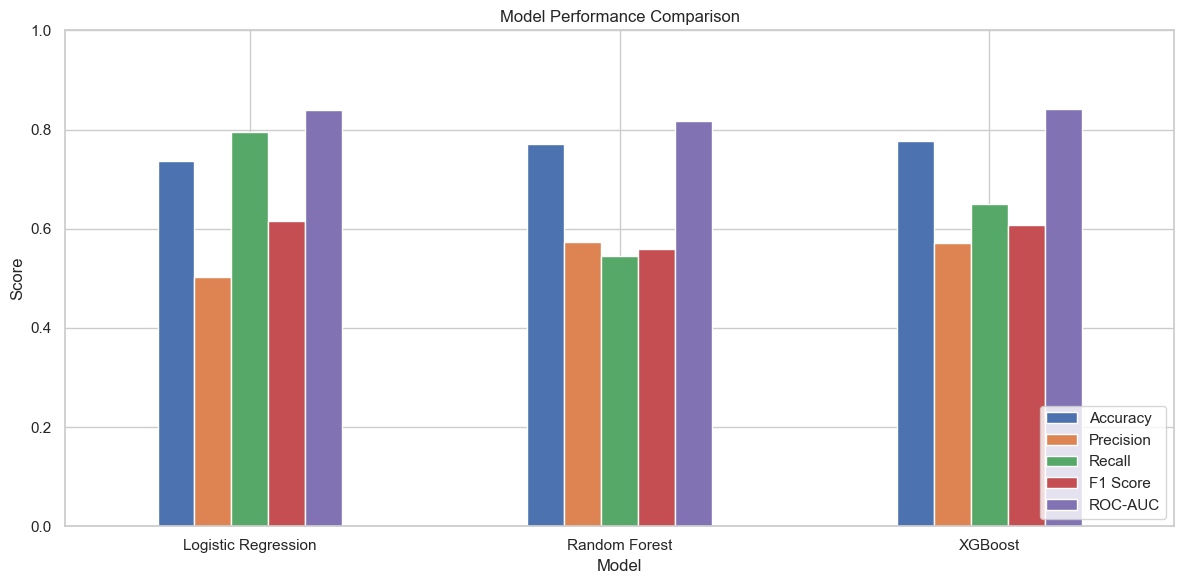

In [76]:
results_plot = results.set_index('Model')

results_plot.plot(
    kind='bar',
    figsize=(12, 6)
)

plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

## **Phase 9: Hyperparameter Tunning**

### Step1: Appply hyperparameter tuning to the model

In [78]:
# import the libraries
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np

### 1. Logistic Regression Hyperparameter Tuning

In [80]:
logistic_param_grid = {
    'model__C': [0.01, 0.1, 1, 10, 100],
    'model__solver': ['liblinear', 'lbfgs']
}

logistic_search = RandomizedSearchCV(
    estimator=logistic_pipeline,
    param_distributions=logistic_param_grid,
    n_iter=8,
    scoring='f1',
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

logistic_search.fit(X_train, y_train)

print("Best Logistic Regression Parameters:")
print(logistic_search.best_params_)

print("\nBest Cross-Validation F1 Score:")
print(logistic_search.best_score_)

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best Logistic Regression Parameters:
{'model__solver': 'lbfgs', 'model__C': 0.01}

Best Cross-Validation F1 Score:
0.6329525418080664


### 2. Random Forest Hyperparameter Tuning

In [82]:
rf_param_grid = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [None, 10, 20, 30],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4]
}

rf_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=rf_param_grid,
    n_iter=10,
    scoring='f1',
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

rf_search.fit(X_train, y_train)

print("Best Random Forest Parameters:")
print(rf_search.best_params_)

print("\nBest Cross-Validation F1 Score:")
print(rf_search.best_score_)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best Random Forest Parameters:
{'model__n_estimators': 100, 'model__min_samples_split': 2, 'model__min_samples_leaf': 4, 'model__max_depth': 10}

Best Cross-Validation F1 Score:
0.6272663121711998


### 3. XGBoost Hyperparameter Tuning

In [84]:
xgb_param_grid = {
    'model__n_estimators': [100, 200, 300],
    'model__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'model__max_depth': [3, 4, 5, 6],
    'model__subsample': [0.7, 0.8, 1.0],
    'model__colsample_bytree': [0.7, 0.8, 1.0]
}

xgb_search = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=xgb_param_grid,
    n_iter=10,
    scoring='f1',
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

xgb_search.fit(X_train, y_train)

print("Best XGBoost Parameters:")
print(xgb_search.best_params_)

print("\nBest Cross-Validation F1 Score:")
print(xgb_search.best_score_)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best XGBoost Parameters:
{'model__subsample': 0.7, 'model__n_estimators': 200, 'model__max_depth': 6, 'model__learning_rate': 0.01, 'model__colsample_bytree': 0.7}

Best Cross-Validation F1 Score:
0.6369362907409598


### Step2: Evaluate the Tuned Models

In [86]:
# Get best models
best_logistic = logistic_search.best_estimator_
best_rf = rf_search.best_estimator_
best_xgb = xgb_search.best_estimator_


# Predictions
y_pred_logistic_tuned = best_logistic.predict(X_test)
y_pred_rf_tuned = best_rf.predict(X_test)
y_pred_xgb_tuned = best_xgb.predict(X_test)


# Probabilities
y_prob_logistic_tuned = best_logistic.predict_proba(X_test)[:, 1]
y_prob_rf_tuned = best_rf.predict_proba(X_test)[:, 1]
y_prob_xgb_tuned = best_xgb.predict_proba(X_test)[:, 1]


# Evaluate
evaluate_model(
    "Tuned Logistic Regression",
    y_test,
    y_pred_logistic_tuned,
    y_prob_logistic_tuned
)

evaluate_model(
    "Tuned Random Forest",
    y_test,
    y_pred_rf_tuned,
    y_prob_rf_tuned
)

evaluate_model(
    "Tuned XGBoost",
    y_test,
    y_pred_xgb_tuned,
    y_prob_xgb_tuned
)

Tuned Logistic Regression
Accuracy : 0.7431
Precision: 0.5107
Recall   : 0.7674
F1 Score : 0.6132
ROC-AUC  : 0.8372

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.90      0.73      0.81      1035
       Churn       0.51      0.77      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.79      0.74      0.76      1409

Tuned Random Forest
Accuracy : 0.7672
Precision: 0.5496
Recall   : 0.6818
F1 Score : 0.6086
ROC-AUC  : 0.8350

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.87      0.80      0.83      1035
       Churn       0.55      0.68      0.61       374

    accuracy                           0.77      1409
   macro avg       0.71      0.74      0.72      1409
weighted avg       0.79      0.77      0.77      1409

Tuned XGBoost
Accuracy : 0.7700
Precision: 0.5519
Recall   : 0.7112
F1 S

## **Phase 10: Final Model Comparison**

In [88]:
tuned_results = pd.DataFrame({
    'Model': [
        'Tuned Logistic Regression',
        'Tuned Random Forest',
        'Tuned XGBoost'
    ],
    
    'Accuracy': [
        accuracy_score(y_test, y_pred_logistic_tuned),
        accuracy_score(y_test, y_pred_rf_tuned),
        accuracy_score(y_test, y_pred_xgb_tuned)
    ],
    
    'Precision': [
        precision_score(y_test, y_pred_logistic_tuned),
        precision_score(y_test, y_pred_rf_tuned),
        precision_score(y_test, y_pred_xgb_tuned)
    ],
    
    'Recall': [
        recall_score(y_test, y_pred_logistic_tuned),
        recall_score(y_test, y_pred_rf_tuned),
        recall_score(y_test, y_pred_xgb_tuned)
    ],
    
    'F1 Score': [
        f1_score(y_test, y_pred_logistic_tuned),
        f1_score(y_test, y_pred_rf_tuned),
        f1_score(y_test, y_pred_xgb_tuned)
    ],
    
    'ROC-AUC': [
        roc_auc_score(y_test, y_prob_logistic_tuned),
        roc_auc_score(y_test, y_prob_rf_tuned),
        roc_auc_score(y_test, y_prob_xgb_tuned)
    ]
})

tuned_results = tuned_results.round(4)

tuned_results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Tuned Logistic Regression,0.7431,0.5107,0.7674,0.6132,0.8372
1,Tuned Random Forest,0.7672,0.5496,0.6818,0.6086,0.8350
2,Tuned XGBoost,0.7700,0.5519,0.7112,0.6215,0.8408


#### Results: XGBoost has BEST F1 Score with 62% and overall accuracy is 77%

## **Phase 11: Final Model Selection**

In [91]:
# Find the model with the highest F1 score

best_model_name = tuned_results.loc[
    tuned_results['F1 Score'].idxmax(),
    'Model'
]

print("Best Model based on F1 Score:")
print(best_model_name)


if best_model_name == 'Tuned Logistic Regression':
    final_model = best_logistic

elif best_model_name == 'Tuned Random Forest':
    final_model = best_rf

elif best_model_name == 'Tuned XGBoost':
    final_model = best_xgb

print("\nFinal model selected:")
print(best_model_name)

Best Model based on F1 Score:
Tuned XGBoost

Final model selected:
Tuned XGBoost


#### Result: Final Model Selection is XGBoost

## **Phase 12: Final Model Evaluation**

### **Model Performance**

In [94]:
# Final model predictions

y_pred_final = final_model.predict(X_test)

# Probability of Churn = 1
y_prob_final = final_model.predict_proba(X_test)[:, 1]

# Calculate metrics

final_accuracy = accuracy_score(y_test, y_pred_final)
final_precision = precision_score(y_test, y_pred_final)
final_recall = recall_score(y_test, y_pred_final)
final_f1 = f1_score(y_test, y_pred_final)
final_roc_auc = roc_auc_score(y_test, y_prob_final)

print("=" * 60)
print("FINAL MODEL PERFORMANCE")
print("=" * 60)

print(f"Model     : {best_model_name}")
print(f"Accuracy  : {final_accuracy:.4f}")
print(f"Precision : {final_precision:.4f}")
print(f"Recall    : {final_recall:.4f}")
print(f"F1 Score  : {final_f1:.4f}")
print(f"ROC-AUC   : {final_roc_auc:.4f}")

print("\nClassification Report")
print("=" * 60)

print(
    classification_report(
        y_test,
        y_pred_final,
        target_names=['No Churn', 'Churn']
    )
)

FINAL MODEL PERFORMANCE
Model     : Tuned XGBoost
Accuracy  : 0.7700
Precision : 0.5519
Recall    : 0.7112
F1 Score  : 0.6215
ROC-AUC   : 0.8408

Classification Report
              precision    recall  f1-score   support

    No Churn       0.88      0.79      0.83      1035
       Churn       0.55      0.71      0.62       374

    accuracy                           0.77      1409
   macro avg       0.72      0.75      0.73      1409
weighted avg       0.80      0.77      0.78      1409



## **Phase 13: Final Model Confusion Matrix**

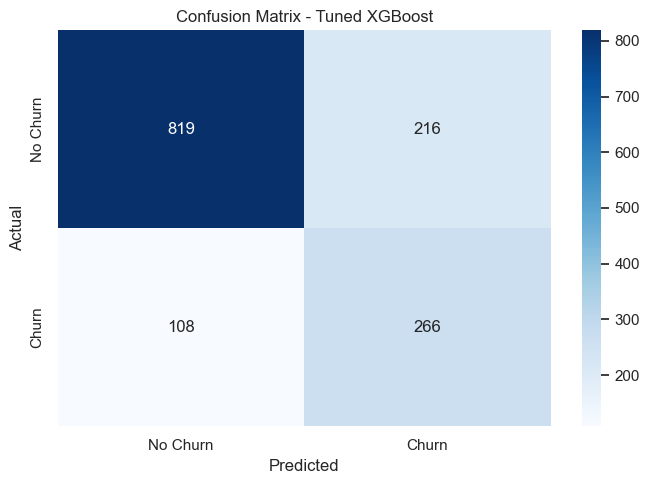

In [96]:
# Confusion Matrix

cm = confusion_matrix(y_test, y_pred_final)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No Churn', 'Churn'],
    yticklabels=['No Churn', 'Churn']
)

plt.title(f'Confusion Matrix - {best_model_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.tight_layout()
plt.show()

### Results

- FN = False Negative

- Customers who actually churned but the model predicted they would not churn.

- For a business, these are potentially the most costly mistakes because the company may fail to intervene before those customers leave.

### 1. Final ROC Curve

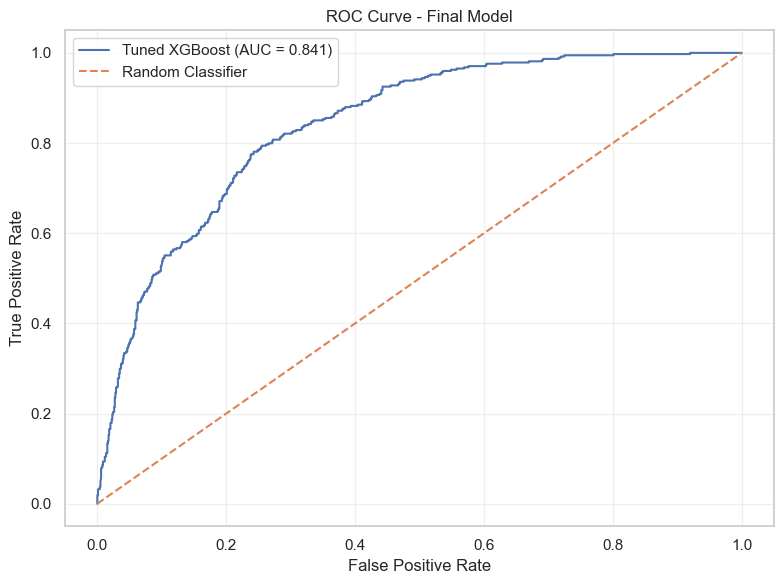

In [99]:
# ROC Curve

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob_final
)

roc_auc = roc_auc_score(
    y_test,
    y_prob_final
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f'{best_model_name} (AUC = {roc_auc:.3f})'
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    label='Random Classifier'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Final Model')

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

#### ROC-AUC = 0.8372

### 2..Feature Interpretability

In [102]:
# Extract feature names from preprocessing pipeline

feature_names = final_model.named_steps[
    'preprocessor'
].get_feature_names_out()

feature_names = [
    name.replace('num__', '')
        .replace('cat__', '')
    for name in feature_names
]

print("Number of model features:", len(feature_names))

Number of model features: 45


### 3. XGBoost or Random Forest becomes the final model

In [104]:
if 'XGBoost' in best_model_name or 'Random Forest' in best_model_name:

    importances = final_model.named_steps[
        'model'
    ].feature_importances_

    feature_importance = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    })

    feature_importance = feature_importance.sort_values(
        'Importance',
        ascending=False
    )

    display(feature_importance.head(20))

,Feature,Importance
36,Contract_Month-to-month,0.280651
18,OnlineSecurity_No,0.089409
27,TechSupport_No,0.052383
38,Contract_Two year,0.047735
16,InternetService_Fiber optic,0.045214
43,PaymentMethod_Electronic check,0.034878
20,OnlineSecurity_Yes,0.031855
19,OnlineSecurity_No internet service,0.030682
37,Contract_One year,0.028880
15,InternetService_DSL,0.024973


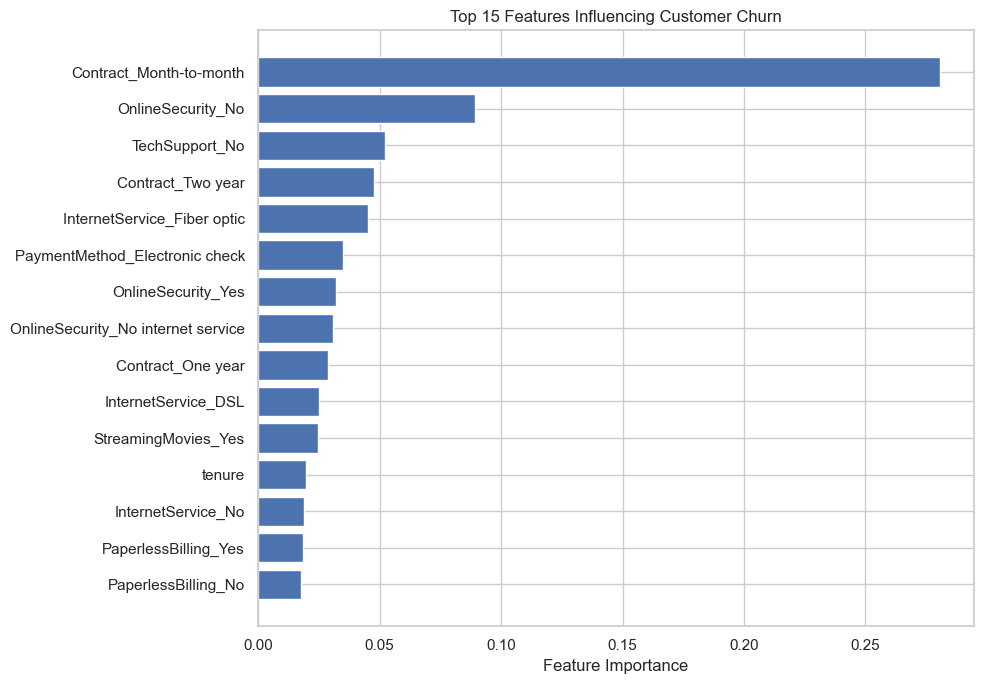

In [105]:
top_features = feature_importance.head(15).sort_values(
    'Importance'
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features['Feature'],
    top_features['Importance']
)

plt.title('Top 15 Features Influencing Customer Churn')
plt.xlabel('Feature Importance')

plt.tight_layout()
plt.show()

## **Phase 14: New Customer Prediction**

In [107]:
def predict_new_customer():

    print("=" * 60)
    print("        CUSTOMER CHURN PREDICTION")
    print("=" * 60)

    gender = input("Gender (Male/Female): ")

    SeniorCitizen = int(
        input("Senior Citizen (0 = No, 1 = Yes): ")
    )

    Partner = input("Partner (Yes/No): ")

    Dependents = input("Dependents (Yes/No): ")

    tenure = int(
        input("Tenure in months: ")
    )

    PhoneService = input("Phone Service (Yes/No): ")

    MultipleLines = input(
        "Multiple Lines (Yes/No/No phone service): "
    )

    InternetService = input(
        "Internet Service (DSL/Fiber optic/No): "
    )

    OnlineSecurity = input(
        "Online Security (Yes/No/No internet service): "
    )

    OnlineBackup = input(
        "Online Backup (Yes/No/No internet service): "
    )

    DeviceProtection = input(
        "Device Protection (Yes/No/No internet service): "
    )

    TechSupport = input(
        "Tech Support (Yes/No/No internet service): "
    )

    StreamingTV = input(
        "Streaming TV (Yes/No/No internet service): "
    )

    StreamingMovies = input(
        "Streaming Movies (Yes/No/No internet service): "
    )

    Contract = input(
        "Contract (Month-to-month/One year/Two year): "
    )

    PaperlessBilling = input(
        "Paperless Billing (Yes/No): "
    )

    PaymentMethod = input(
        "Payment Method "
        "(Electronic check/Mailed check/"
        "Bank transfer (automatic)/"
        "Credit card (automatic)): "
    )

    MonthlyCharges = float(
        input("Monthly Charges: ")
    )

    TotalCharges = float(
        input("Total Charges: ")
    )


    # Create dataframe for one new customer

    new_customer = pd.DataFrame({

        'gender': [gender],

        'SeniorCitizen': [SeniorCitizen],

        'Partner': [Partner],

        'Dependents': [Dependents],

        'tenure': [tenure],

        'PhoneService': [PhoneService],

        'MultipleLines': [MultipleLines],

        'InternetService': [InternetService],

        'OnlineSecurity': [OnlineSecurity],

        'OnlineBackup': [OnlineBackup],

        'DeviceProtection': [DeviceProtection],

        'TechSupport': [TechSupport],

        'StreamingTV': [StreamingTV],

        'StreamingMovies': [StreamingMovies],

        'Contract': [Contract],

        'PaperlessBilling': [PaperlessBilling],

        'PaymentMethod': [PaymentMethod],

        'MonthlyCharges': [MonthlyCharges],

        'TotalCharges': [TotalCharges]
    })


    # Make prediction

    prediction = final_model.predict(
        new_customer
    )[0]

    probability = final_model.predict_proba(
        new_customer
    )[0][1]


    print("\n" + "=" * 60)
    print("              PREDICTION RESULT")
    print("=" * 60)

    if prediction == 1:

        print("Prediction      : CUSTOMER WILL CHURN")

        print(
            f"Churn Probability: {probability:.2%}"
        )

        print("Risk Level      : HIGH")

        print(
            "\nRecommendation:"
        )

        print(
            "Consider offering retention incentives, "
            "contract upgrades, or targeted customer support."
        )

    else:

        print("Prediction      : CUSTOMER WILL NOT CHURN")

        print(
            f"Churn Probability: {probability:.2%}"
        )

        print("Risk Level      : LOW")

        print(
            "\nRecommendation:"
        )

        print(
            "Continue regular customer engagement "
            "and service monitoring."
        )

    print("=" * 60)

## Run the Prediction

#### For example: enter this input

- Gender (Male/Female):  Female

- Senior Citizen (0 = No, 1 = Yes):  0

- Partner (Yes/No):  Yes

- Dependents (Yes/No):  No

- Tenure in months:  5

- Phone Service (Yes/No):  Yes

- Multiple Lines (Yes/No/No phone service):  No

- Internet Service (DSL/Fiber optic/No):  Fiber optic

- Online Security (Yes/No/No internet service):  Yes

- Online Backup (Yes/No/No internet service):  Yes

- Device Protection (Yes/No/No internet service):  Yes

- Tech Support (Yes/No/No internet service):  Yes

- Streaming TV (Yes/No/No internet service):  No

- Streaming Movies (Yes/No/No internet service):  No

- Contract (Month-to-month/One year/Two year):  One year

- Paperless Billing (Yes/No):  Yes

- Payment Method (Electronic check/Mailed check/Bank transfer (automatic)/Credit card (automatic)):  Credit

- Monthly Charges:  100

- Total Charges:  150

In [110]:
predict_new_customer()

        CUSTOMER CHURN PREDICTION


Gender (Male/Female):  Female
Senior Citizen (0 = No, 1 = Yes):  0
Partner (Yes/No):  Yes
Dependents (Yes/No):  No
Tenure in months:  5
Phone Service (Yes/No):  Yes
Multiple Lines (Yes/No/No phone service):  No
Internet Service (DSL/Fiber optic/No):  Fiber optic
Online Security (Yes/No/No internet service):  Yes
Online Backup (Yes/No/No internet service):  Yes
Device Protection (Yes/No/No internet service):  Yes
Tech Support (Yes/No/No internet service):  Yes
Streaming TV (Yes/No/No internet service):  No
Streaming Movies (Yes/No/No internet service):  No
Contract (Month-to-month/One year/Two year):  One year
Paperless Billing (Yes/No):  Yes
Payment Method (Electronic check/Mailed check/Bank transfer (automatic)/Credit card (automatic)):  Credit
Monthly Charges:  100
Total Charges:  150



              PREDICTION RESULT
Prediction      : CUSTOMER WILL NOT CHURN
Churn Probability: 20.81%
Risk Level      : LOW

Recommendation:
Continue regular customer engagement and service monitoring.


## Key isnights

**1. Customer churn is imbalanced** — non-churners are significantly higher than churners, making churn detection more challenging.

**2. Senior citizens show higher churn tendency**, indicating this group may require additional retention attention.

**3. Fiber optic customers have higher churn** compared with DSL customers, suggesting possible concerns related to pricing, service quality, or reliability.

**4. Customers with higher MonthlyCharges tend to churn more**, indicating possible price sensitivity.

**5. Short-tenure customers are more likely to churn**, making the early customer lifecycle an important retention period.

**6. Electronic-check users have the highest churn rate** among payment methods analyzed.

**7. Month-to-month contracts are a major churn-risk segment**, as shown by the contract analysis and model results.

**8.** The tuned models show that **Logistic Regression achieved the highest F1 score (64.70%), while XGBoost achieved 66.22% recall**, making both useful depending on whether the priority is balanced performance or catching more churners.

## Recommendations

**1. Target short-tenure customers**

- Provide strong onboarding and early engagement.
    
- Conduct 30/60/90-day follow-ups.

- Offer early loyalty incentives.

**2. Encourage longer-term contracts**

- Provide discounts or loyalty benefits for customers moving from month-to-month to one-year/two-year contracts.

**3. Improve Fiber Optic service**

- Investigate service reliability, pricing, technical problems, and customer satisfaction.

**4. Address high monthly charges**

- Introduce flexible pricing, discounts, or bundled service plans for price-sensitive customers.

**5. Promote alternative payment methods**

- Encourage electronic-check users to switch to automatic bank transfer or credit-card payments.

**6. Create targeted senior-citizen retention programs**

- Offer personalized discounts, loyalty rewards, and dedicated support.

**7. Use the churn model for targeted campaigns**

- Identify high-risk customers and prioritize them for personalized retention offers rather than applying the same strategy to every customer.

**8. Monitor churn continuously**
                                             
- Track predicted high-risk customers and evaluate whether retention campaigns actually reduce churn over time.

## Conclusion

This project successfully developed an **Interactive Prototype** with **analytical pipeline**. Customer Churn Prediction system using Machine Learning.

The analysis identified important customer segments associated with churn, particularly **month-to-month contract customers, short-tenured customers, fiber-optic users, electronic-check users, and customers without certain support/security services.** The exploratory analysis also revealed strong relationships between **tenure** and **TotalCharges** and between **MonthlyCharges** and **TotalCharges**.

Three machine learning models were developed and evaluated:

- Logistic Regression

- Random Forest

- XGBoost

After hyperparameter tuning, **XGBoost was selected as the final model** based on its highest F1 score.

The final model achieved:

**77.00% Accuracy** | **55.19% Precision** | **71.12% Recall** | **62.15% F1 Score** | **84.08% ROC-AUC**

- The model's **71.12% recall for churn** makes it useful for identifying a substantial proportion of customers who are at risk of leaving. The model can therefore be used as a decision-support tool to help the business prioritize retention efforts.

- The project also includes an interactive **new-customer prediction system**, allowing the trained model to estimate churn probability for individual customers.

- Overall, this project demonstrates how machine learning can transform customer data into **predictive insights and actionable retention strategies**, helping organizations proactively identify high-risk customers and potentially reduce customer attrition.